In [14]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [15]:
diabetes = pd.read_csv('diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
col = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
diabetes[col] = diabetes[col].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.743719,0.590164,0.353535,0.000000,0.500745,0.234415,50,1
1,0.058824,0.427136,0.540984,0.292929,0.000000,0.396423,0.116567,31,0
2,0.470588,0.919598,0.524590,0.000000,0.000000,0.347243,0.253629,32,1
3,0.058824,0.447236,0.540984,0.232323,0.111111,0.418778,0.038002,21,0
4,0.000000,0.688442,0.327869,0.353535,0.198582,0.642325,0.943638,33,1


In [17]:
num_preg = tf.feature_column.numeric_column('Pregnancies')
plasma_gluc = tf.feature_column.numeric_column('Glucose')
dias_press = tf.feature_column.numeric_column('BloodPressure')
tricep = tf.feature_column.numeric_column('SkinThickness')
insulin = tf.feature_column.numeric_column('Insulin')
bmi = tf.feature_column.numeric_column('BMI')
pedigree = tf.feature_column.numeric_column('DiabetesPedigreeFunction')
age = tf.feature_column.numeric_column('age')

<Axes: >

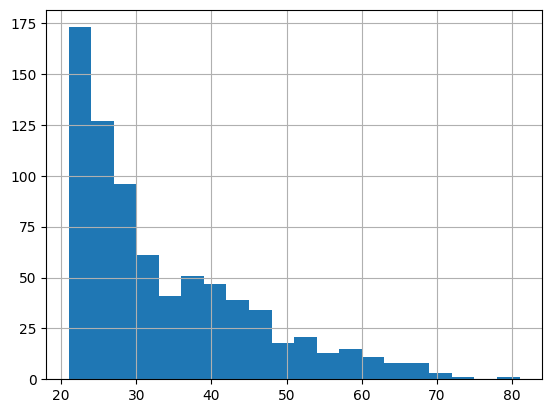

In [18]:
%matplotlib inline
diabetes['Age'].hist(bins=20)

In [19]:
x_data = diabetes.drop('Outcome', axis=1)
labels = diabetes['Outcome']
X_train, X_test, y_train, y_test = train_test_split(x_data, labels, test_size=0.33, random_state=101)


In [20]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy() 

model.fit(X_train_np, y_train, epochs=10, batch_size=10)

predictions = model.predict(X_test_np)
print(predictions)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6363 - loss: 1.2352   
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6658 - loss: 0.6759 
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.6655 - loss: 0.6774
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6450 - loss: 0.6775 
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6418 - loss: 0.6804 
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - accuracy: 0.6451 - loss: 0.6799
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.6402 - loss: 0.6677
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6481 - loss: 0.6624 
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6159 - loss: 0.6793 
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6589 - loss: 0.6642 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[[0.38692722]
 [0.43817222]
 [0.35824546]
 [0.43243387]
 [0.38686657]
 [0.4321246 ]
 [0.43392137]
 [0.3426

In [21]:
loss, accuracy = model.evaluate(X_test_np, y_test, batch_size=10)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6537 - loss: 0.6388  
Test Loss: 0.6441745162010193
Test Accuracy: 0.6574802994728088
